<a href="https://colab.research.google.com/github/Charan-BE21B010/My-Projects/blob/my-projects/Electricity_Forecasting_Demand.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Overview
- You will perform electricity demand forecasting using the data provided in a Google Colaboratory notebook.
- For instructions on using Google Colaboratory, please refer to this [link](https://colab.research.google.com/?hl=ja#scrollTo=Wf5KrEb6vrkR).
- The provided data consists of two types:
  - electricity_demand.csv: Electricity demand values within the Kansai Electric Power (JP) jurisdiction.
  - {location}.csv: Actual weather data for specific locations.

## Rules
- The forecasting target period is January 1, 2023, 00:00:00 – December 31, 2023, 23:00:00.
- Electricity demand values can only be used up until 23:00:00 of the day before the target date.
- There are no restrictions on forecasting methods (choose methods available in the free-tier plan).
- The use of additional data from libraries such as jpholiday is permitted.
  - If additional libraries are used, include the installation command in the notebook (e.g., ! pip install pandas).

## Required Deliverables
Use both code and Markdown as needed to provide the following information:

- Model Development for Electricity Demand Forecasting
  - Justify the choice of method and, if applicable, describe any hypotheses regarding feature engineering.
- Evaluation of Forecasting Performance Using Actual Data
  - Specify and justify the selected evaluation metrics.
- Error Analysis and Model Challenges
- Discuss issues identified through error analysis.
- Hypotheses for Accuracy Improvement
  - Provide potential strategies for enhancing model performance.
- Expected Benefits of Model Deployment
  - Explain the potential impact and advantages of implementing the model.

## Submission
- Once coding and execution are completed in Google Colaboratory, download the executed notebook and submit it.
- Submit your notebook through the designated agent.

Load datasets

In [66]:
import pandas as pd
demand = pd.read_csv("/content/demand.csv")
hikone = pd.read_csv("/content/hikone.csv")

Convert datetime column

In [67]:
demand['datetime'] = pd.to_datetime(demand['datetime'], errors='coerce')
hikone['datetime'] = pd.to_datetime(hikone['datetime'], errors='coerce')

In [68]:
merged_df = pd.merge(demand, hikone, on='datetime', how='inner')

Filtering the year 2023

In [69]:
start_date = '2023-01-01 00:00:00'
end_date = '2023-12-31 23:00:00'
merged_df = merged_df[(merged_df['datetime'] >= start_date) & (merged_df['datetime'] <= end_date)]

Defining the features and target

In [70]:
features = ['temperature', 'humidity', 'wind_speed', 'precipitation','dew_point_temperature']
target = 'actual_performance(10000 kW)'

In [71]:
X = merged_df[features]
y = merged_df[target]

Train-test split

In [72]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Comparing the models

In [73]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

In [48]:
models = {
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "Linear Regression": LinearRegression()
}

Storing the results

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results[name] = {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r2}

Converting the results into DataFrame

In [79]:
results_df = pd.DataFrame(results).T
print(results_df)

                          MAE           MSE        RMSE  R2 Score
Random Forest      233.018237  96410.440851  310.500307  0.038861
Gradient Boosting  228.338354  88304.415612  297.160589  0.119672
Linear Regression  239.320254  95059.844733  308.317766  0.052326


Plot comparison in a single graph

In [80]:
import matplotlib.pyplot as plt
import numpy as np

<BarContainer object of 3 artists>

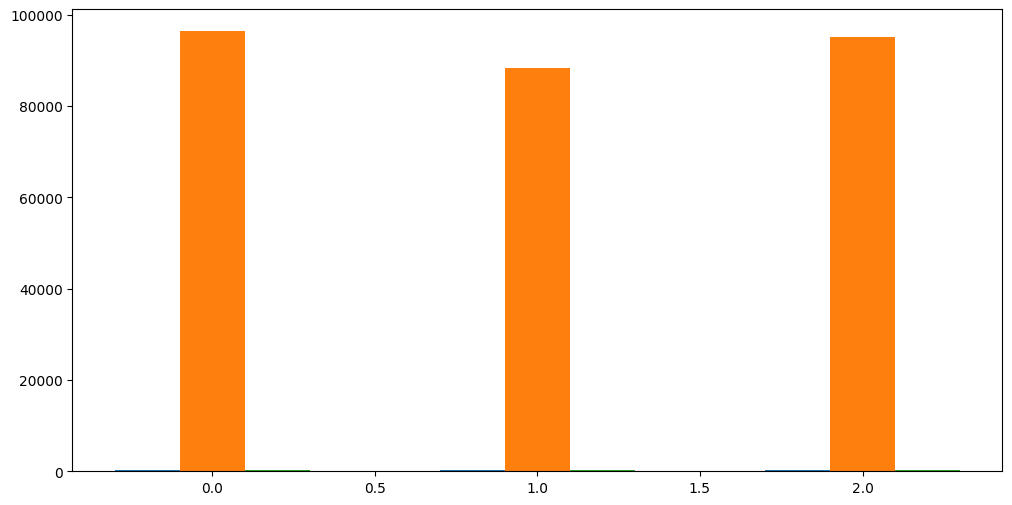

In [81]:
plt.figure(figsize=(12, 6))
bar_width = 0.2
x_labels = list(results_df.index)
x = np.arange(len(x_labels))

plt.bar(x - bar_width, results_df['MAE'], width=bar_width, label='MAE')
plt.bar(x, results_df['MSE'], width=bar_width, label='MSE')
plt.bar(x + bar_width, results_df['RMSE'], width=bar_width, label='RMSE')

Error Analysis

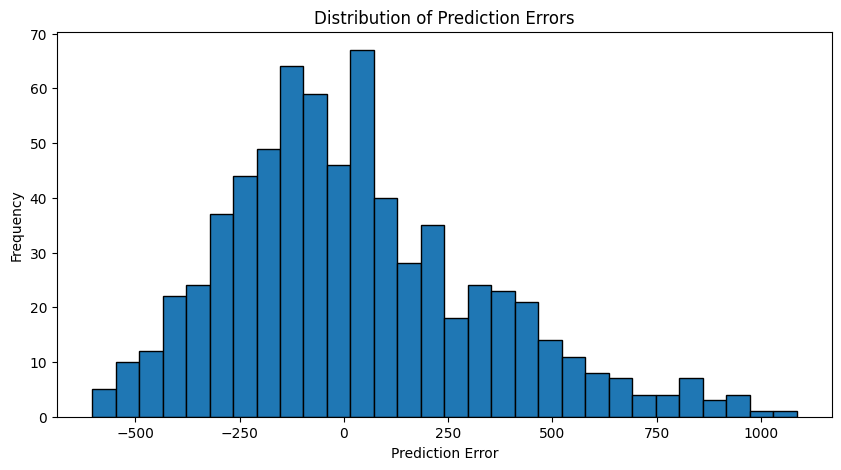

In [83]:
errors = y_test - model.predict(X_test)
plt.figure(figsize=(10, 5))
plt.hist(errors, bins=30, edgecolor='black')
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.show()